# Stage6A — Remaining canonical failures
Artifact reader only. No fitting, calibration, inference, or changed decisions. See the journey chapter for the decision gate.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
root = Path.cwd()
if not (root/'artifacts/stage6a').exists(): root = root.parent
out = root/'artifacts/stage6a'
assert json.loads((out/'independent_review.json').read_text())['passed']
cases = pd.read_csv(out/'case_diagnosis.csv')
display(cases)

,image_id,source_labels,pose_label,size_band,groups,mask_area,failure_category,diagnostic_notes,d1_detected,d1_score_ratio,d1_gt_max_ratio,d1_outside_gt_ratio,d1_pixel_ap,d1_top_patch_inside_gt,d2_detected,d2_score_ratio,d2_gt_max_ratio,d2_outside_gt_ratio,d2_pixel_ap,d2_top_patch_inside_gt
0,0174183097ea8fa63bbe3153,"[""missing""]",canonical,R4,canonical_missing_hit,1238,F5,Descriptive flags; F3 is localization competit...,True,1.428529,1.428529,1.033677,0.877952,True,True,1.471471,1.471471,1.008066,0.888382,True
1,0333ff525de4a8a11f200628,"[""bent""]",canonical,R2,small_hit,119,F5,Descriptive flags; F3 is localization competit...,True,1.732661,1.732661,1.559348,0.330294,True,True,1.571653,1.571653,1.387093,0.431867,True
2,0cfaf8dea93dc0646a1d60dd,"[""melt""]",canonical,R2,small_hit,111,F5,Descriptive flags; F3 is localization competit...,True,1.157158,1.157158,1.064017,0.516865,True,True,1.312145,1.312145,1.126508,0.585346,True
3,156203b86fd0a31b58234f24,"[""melt""]",canonical,R1,small_miss,77,F5,Descriptive flags; F3 is localization competit...,False,0.935747,0.935747,0.912201,0.409646,True,False,0.936116,0.936116,0.928994,0.251812,True
4,19c7eaaf7a7c2b71d5da1dc8,"[""melt""]",canonical,R2,small_miss,107,F4,Descriptive flags; F3 is localization competit...,False,0.943585,0.915541,0.943585,0.030355,False,False,0.978480,0.978480,0.956374,0.205956,True
5,2744e38a1b628fcbf2067bd4,"[""missing""]",canonical,R4,canonical_missing_hit,238,F3,Descriptive flags; F3 is localization competit...,True,1.238677,1.238677,1.159449,0.147402,True,True,1.087992,1.084255,1.087992,0.113339,False
6,31656a11b9780d9f8a2fa83f,"[""scratch"", ""missing""]",canonical,R4,canonical_missing_hit,585,F5,Descriptive flags; F3 is localization competit...,True,1.286588,1.286588,1.030946,0.564961,True,True,1.274031,1.274031,1.052977,0.843545,True
7,454fde2976c690adb252f174,"[""melt""]",canonical,R1,small_hit,92,F3,Descriptive flags; F3 is localization competit...,True,1.056077,0.878396,1.056077,0.009383,False,True,1.128825,1.047315,1.128825,0.105684,False
8,596996fa0816db1d904389d5,"[""bent"", ""melt""]",canonical,R2,small_hit,119,F5,Descriptive flags; F3 is localization competit...,True,1.386434,1.386434,1.296820,0.203508,True,True,1.641402,1.641402,1.506468,0.280791,True
9,5b26e8174612cbac5bf361c6,"[""melt""]",canonical,R2,small_hit,103,F5,Descriptive flags; F3 is localization competit...,True,1.015164,1.015164,0.920337,0.887599,True,True,1.197799,1.197799,1.016995,0.854000,True


In [2]:
display(pd.read_csv(out/'patch_rank_diagnostics.csv'))
display(pd.read_csv(out/'aggregation_diagnostics.csv'))
d = pd.read_csv(out/'feature_distance.csv')
display(d.groupby(['recipe','image_id'])[['nearest_reference_distance','median_top5_reference_distance']].median())

,image_id,recipe,first_gt_patch_rank,top_5_gt_fraction,top_10_gt_fraction,top_20_gt_fraction,GT_overlap_patch_count,native_patch_count
0,0174183097ea8fa63bbe3153,d1,1,1.0,1.0,1.00,43,1024
1,0333ff525de4a8a11f200628,d1,1,0.6,0.6,0.35,9,1024
2,0cfaf8dea93dc0646a1d60dd,d1,1,1.0,0.5,0.40,10,1024
3,156203b86fd0a31b58234f24,d1,1,0.4,0.3,0.20,6,1024
4,19c7eaaf7a7c2b71d5da1dc8,d1,3,0.2,0.1,0.10,8,1024
...,...,...,...,...,...,...,...,...
67,e68d2653f5376170791a8674,d2,1,0.6,0.4,0.30,22,4096
68,ead24842cb7981c9674e9d4e,d2,1,1.0,0.8,0.45,24,4096
69,f210dd5f4d74b3edf87a8edc,d2,1,1.0,0.9,0.50,17,4096
70,f29f971c989e3457da844b2b,d2,1,0.6,0.5,0.45,31,4096


,image_id,recipe,max_GT_patch_score,max_outside_GT_patch_score,top_1_mean,top_3_mean,top_5_mean,top_10_mean,patch_p90,patch_p95,patch_p99,top_1_percent_mean
0,0174183097ea8fa63bbe3153,d1,2.324311,1.681860,2.324311,2.277747,2.248372,2.177151,1.338251,1.449798,2.016551,2.162656
1,0333ff525de4a8a11f200628,d1,2.819154,2.537163,2.819154,2.741833,2.638067,2.484557,1.319963,1.466097,2.122632,2.453099
2,0cfaf8dea93dc0646a1d60dd,d1,1.882772,1.731227,1.882772,1.870766,1.849549,1.751299,1.284237,1.338046,1.562200,1.734303
3,156203b86fd0a31b58234f24,d1,1.522523,1.484212,1.522523,1.504300,1.479464,1.443854,1.282600,1.319964,1.388856,1.438972
4,19c7eaaf7a7c2b71d5da1dc8,d1,1.489645,1.535275,1.535275,1.510292,1.497839,1.476793,1.318129,1.364813,1.446429,1.474051
...,...,...,...,...,...,...,...,...,...,...,...,...
67,e68d2653f5376170791a8674,d2,2.008968,1.956950,2.008968,1.983232,1.945935,1.904336,1.617118,1.670610,1.749130,1.815224
68,ead24842cb7981c9674e9d4e,d2,1.993567,1.841445,1.993567,1.970036,1.951795,1.913743,1.631458,1.671889,1.763150,1.819850
69,f210dd5f4d74b3edf87a8edc,d2,2.203455,2.043598,2.203455,2.194039,2.162938,2.107451,1.618203,1.664711,1.742557,1.891510
70,f29f971c989e3457da844b2b,d2,2.205812,2.056503,2.205812,2.155101,2.111014,2.038215,1.599493,1.661943,1.777997,1.876290


nearest_reference_distance  \
recipe image_id                                               
d1     0174183097ea8fa63bbe3153                    1.826746   
       0333ff525de4a8a11f200628                    2.375608   
       0cfaf8dea93dc0646a1d60dd                    1.685820   
       156203b86fd0a31b58234f24                    1.400183   
       19c7eaaf7a7c2b71d5da1dc8                    1.314047   
...                                                     ...   
d2     e68d2653f5376170791a8674                    1.512295   
       ead24842cb7981c9674e9d4e                    1.741430   
       f210dd5f4d74b3edf87a8edc                    2.021825   
       f29f971c989e3457da844b2b                    1.473593   
       fea34ce33cdd25b0ede4efe4                    2.060338   

                                 median_top5_reference_distance  
recipe image_id                                                  
d1     0174183097ea8fa63bbe3153                        1.865998  
       0333ff525de4a8a11f200628                        2.458911  
       0cfaf8dea93dc0646a1d60dd                        1.810531  
       156203b86fd0a31b58234f24                        1.570476  
       19c7eaaf7a7c2b71d5da1dc8                        1.548240  
...                                                         ...  
d2     e68d2653f5376170791a8674                        1.676154  
       ead24842cb7981c9674e9d4e                        1.923533  
       f210dd5f4d74b3edf87a8edc                        2.136184  
       f29f971c989e3457da844b2b                        1.743335  
       fea34ce33cdd25b0ede4efe4                        2.164663  

[72 rows x 2 columns]

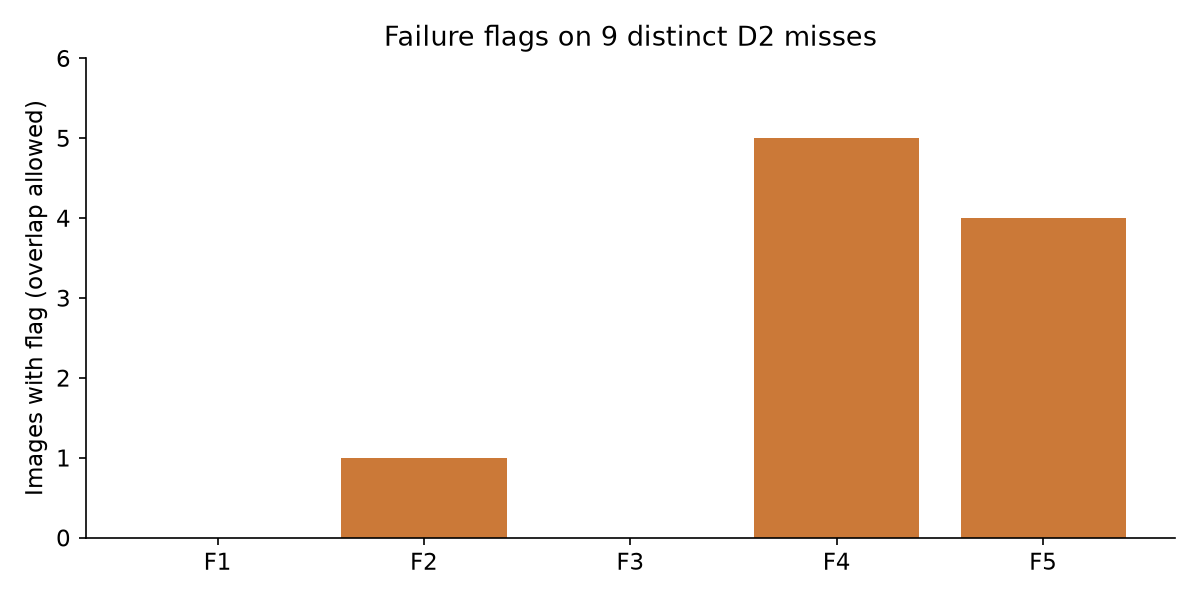

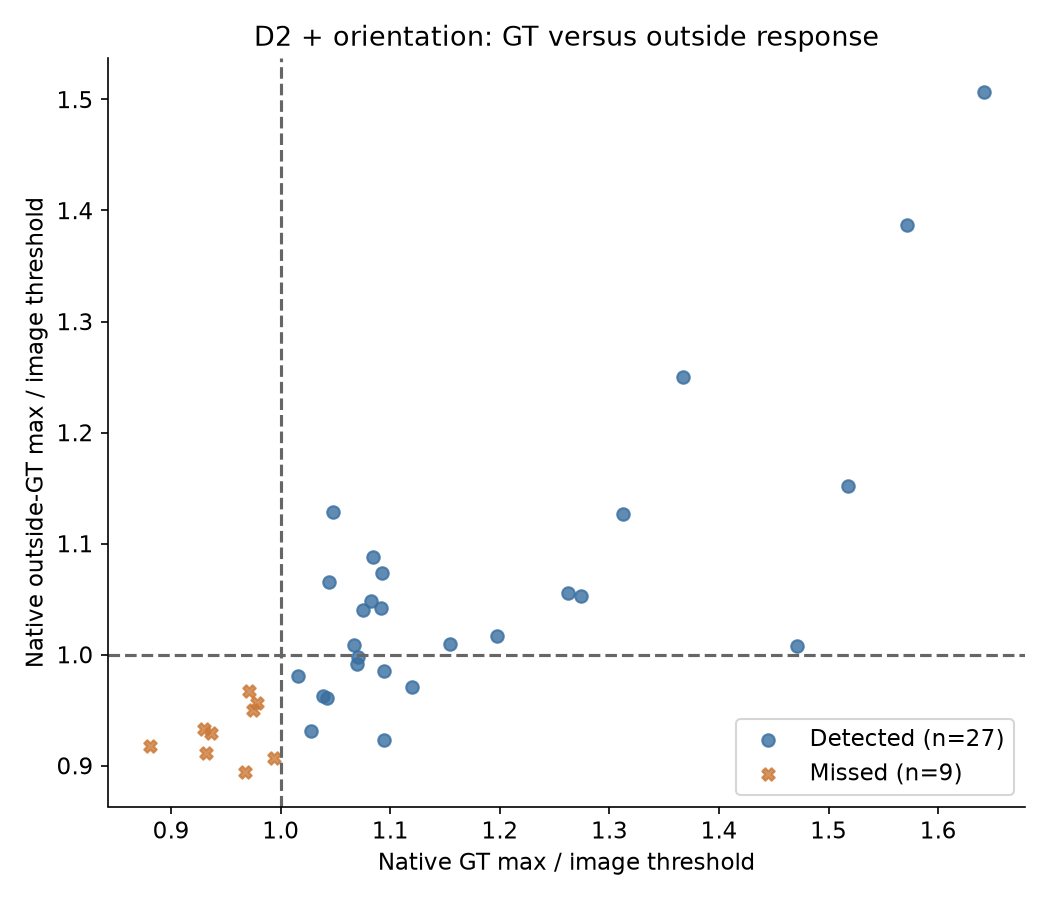

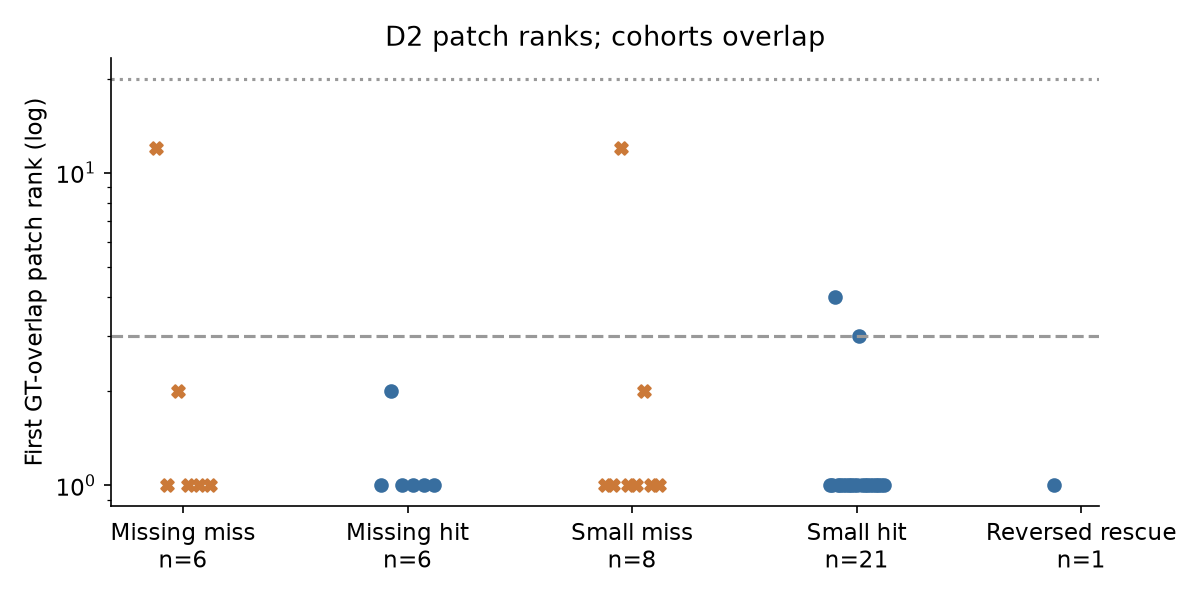

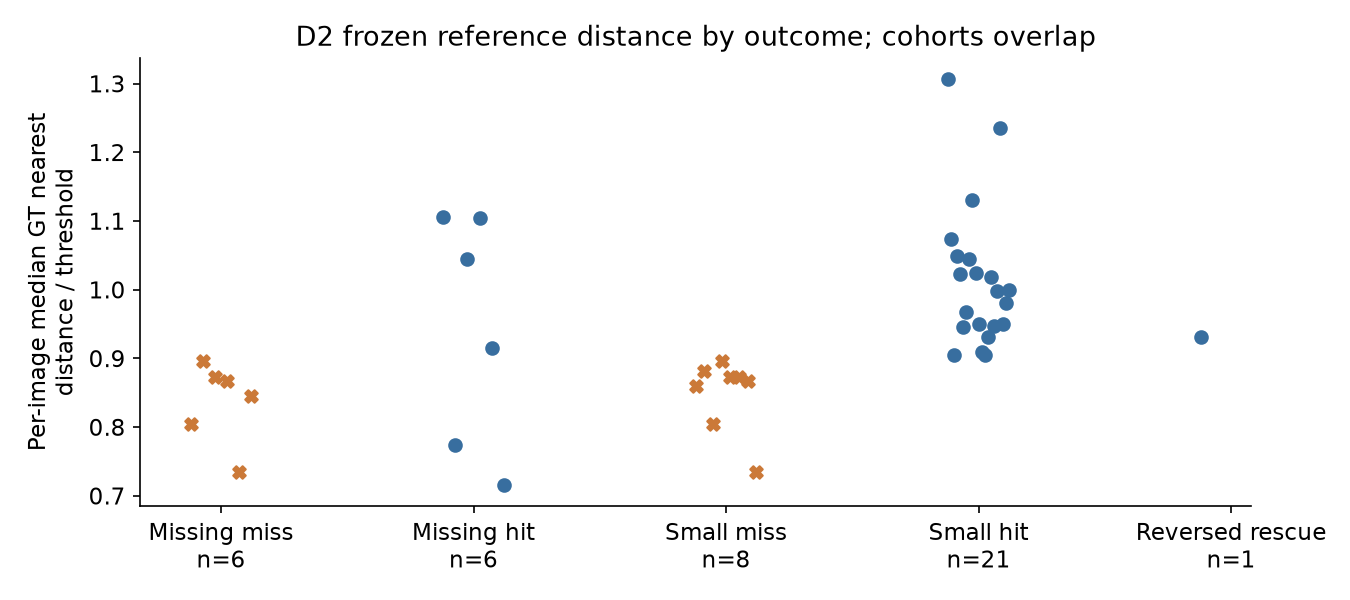

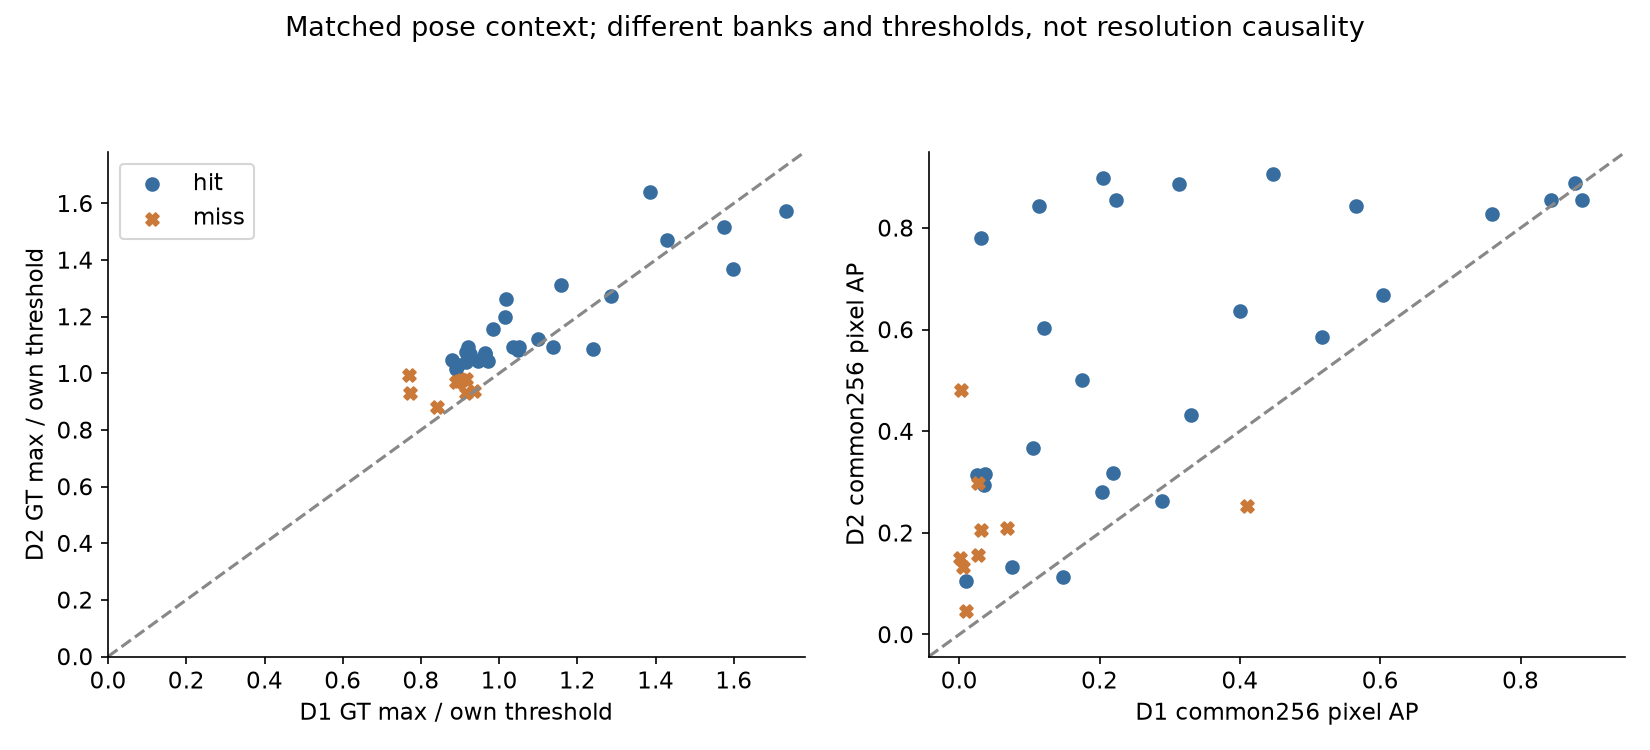

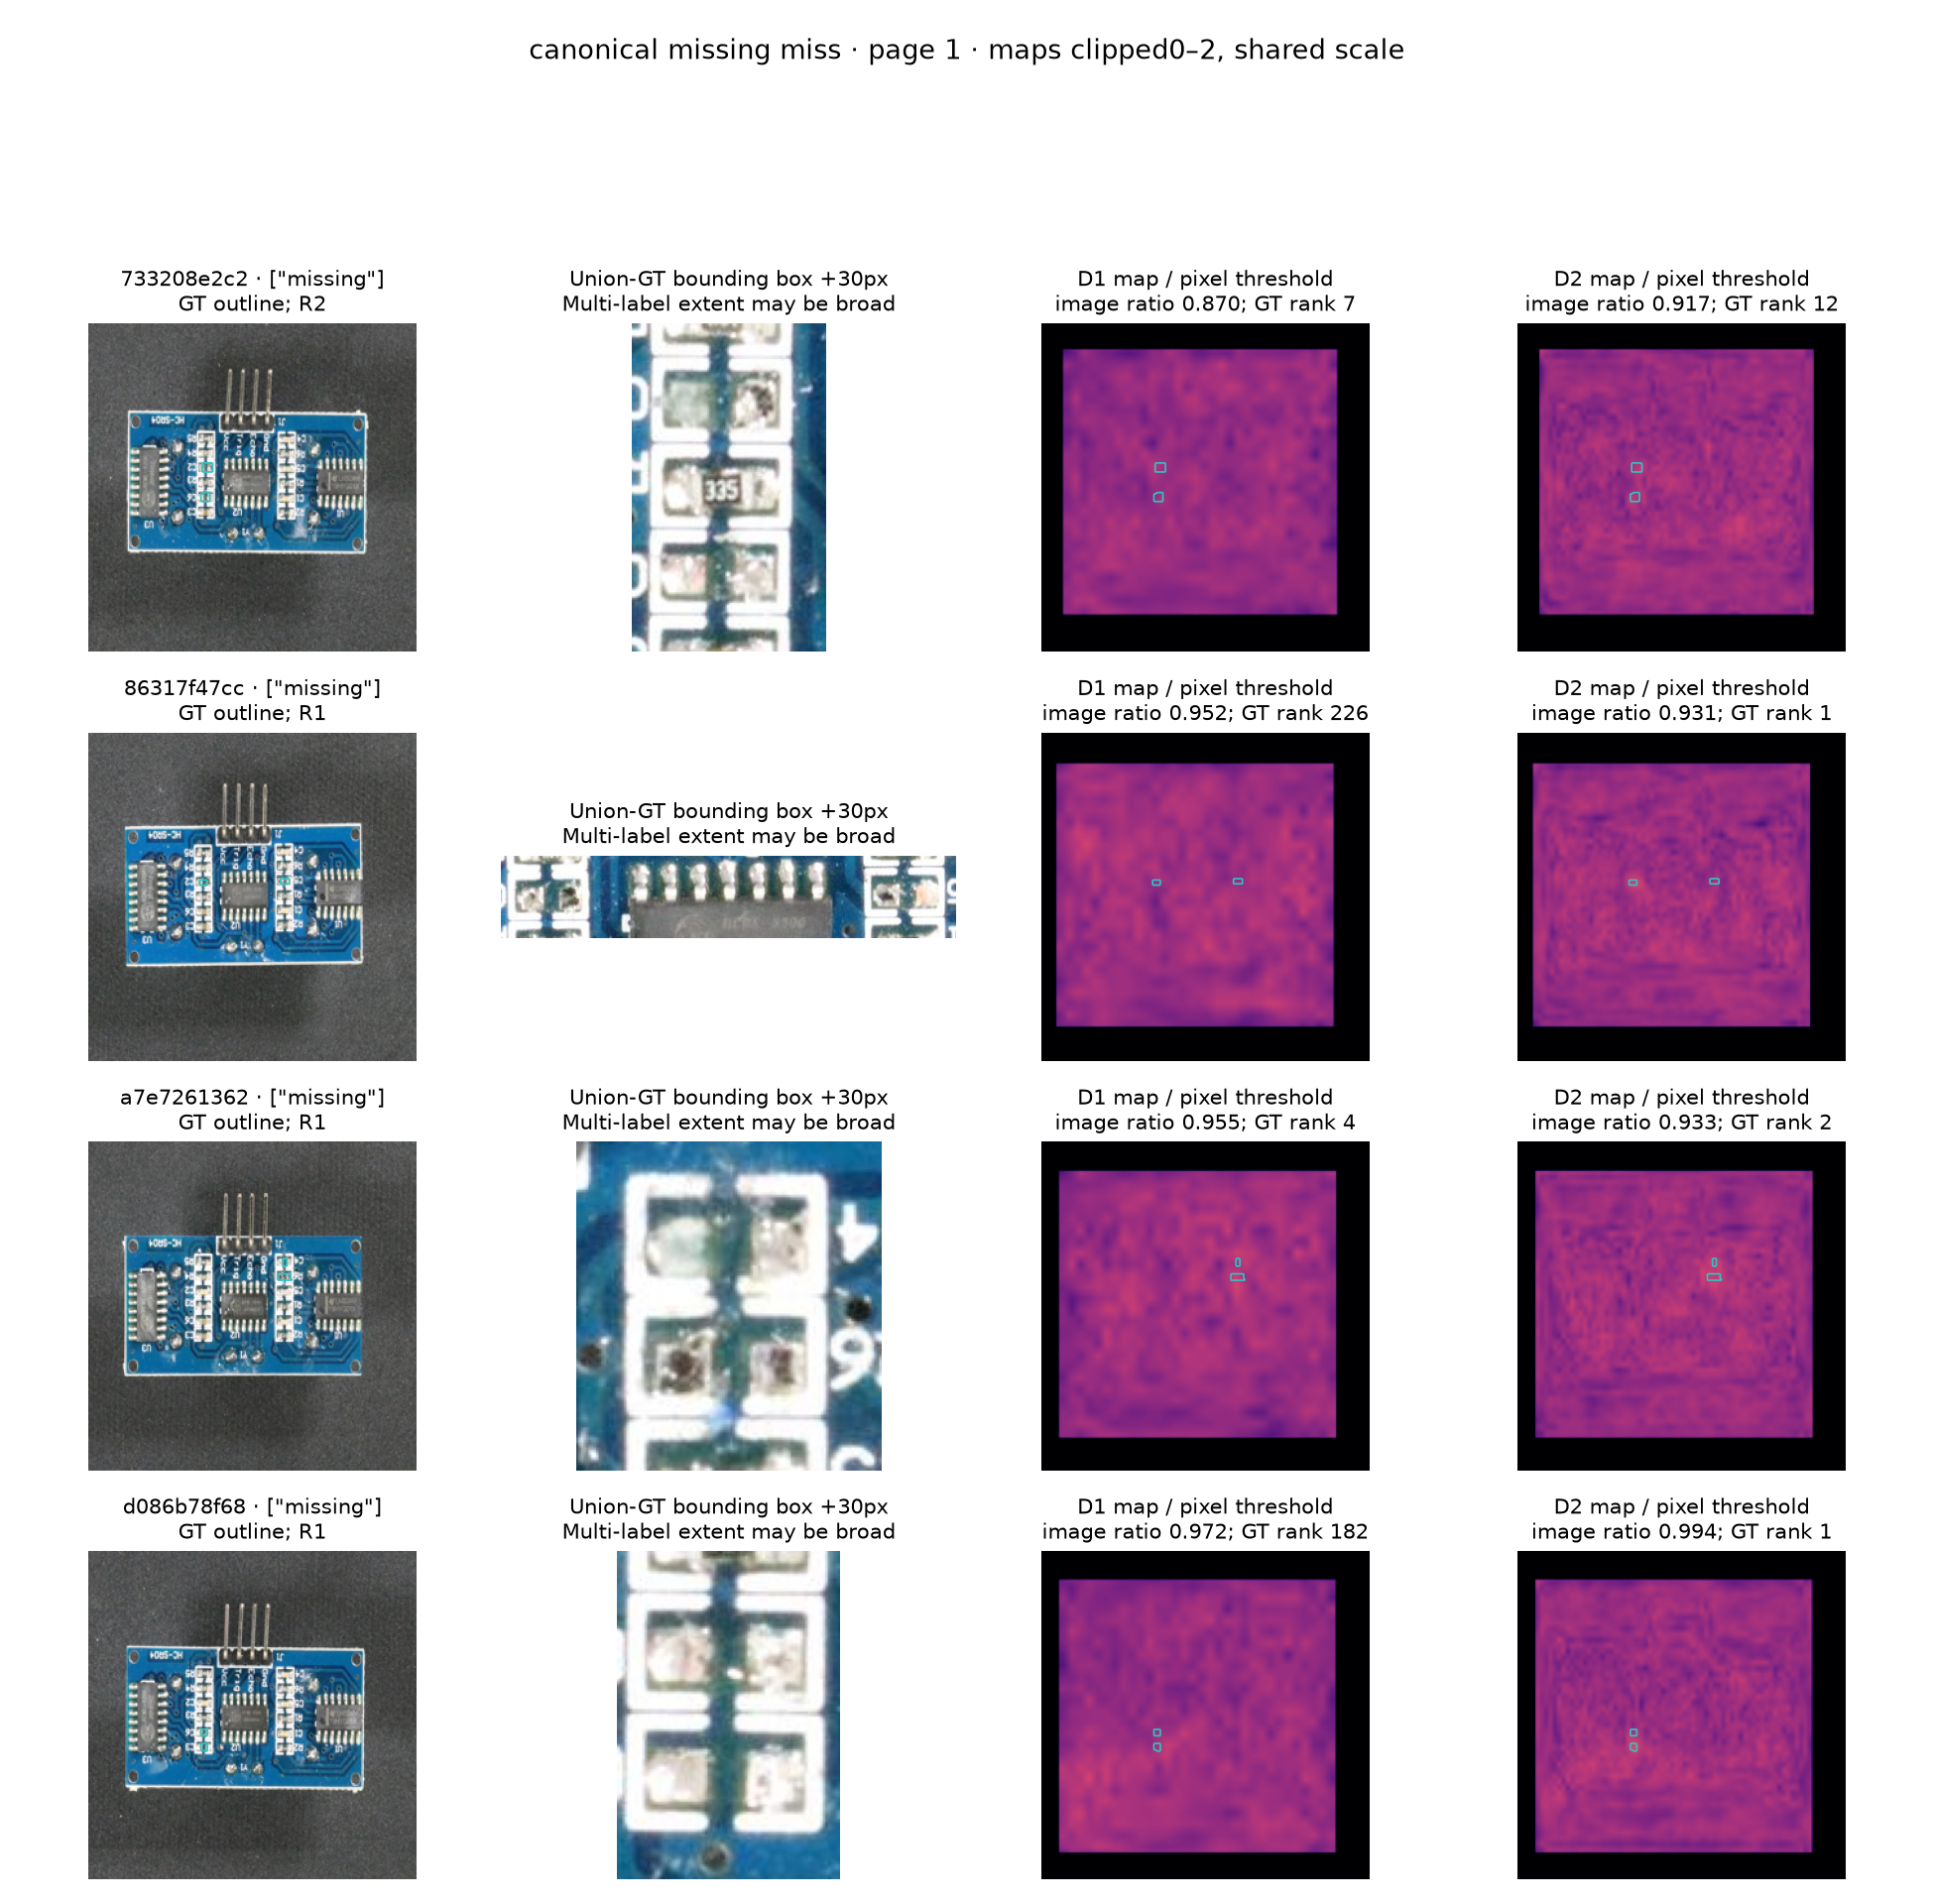

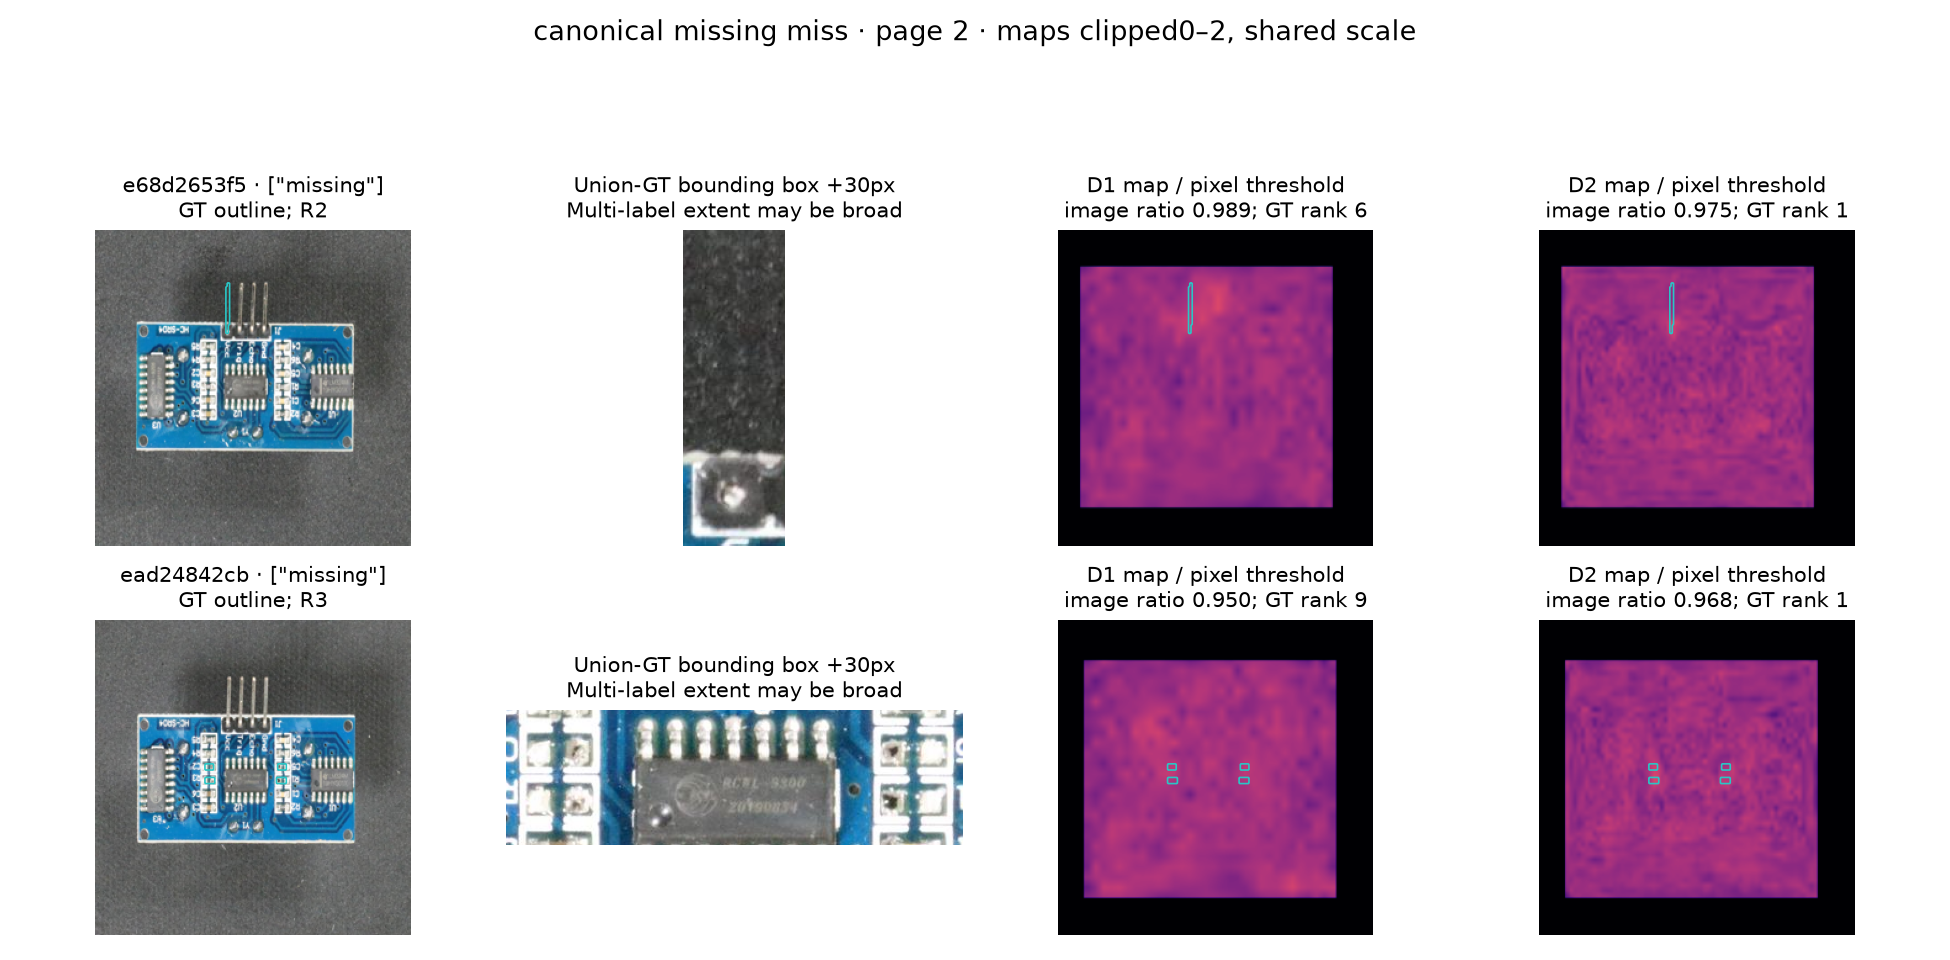

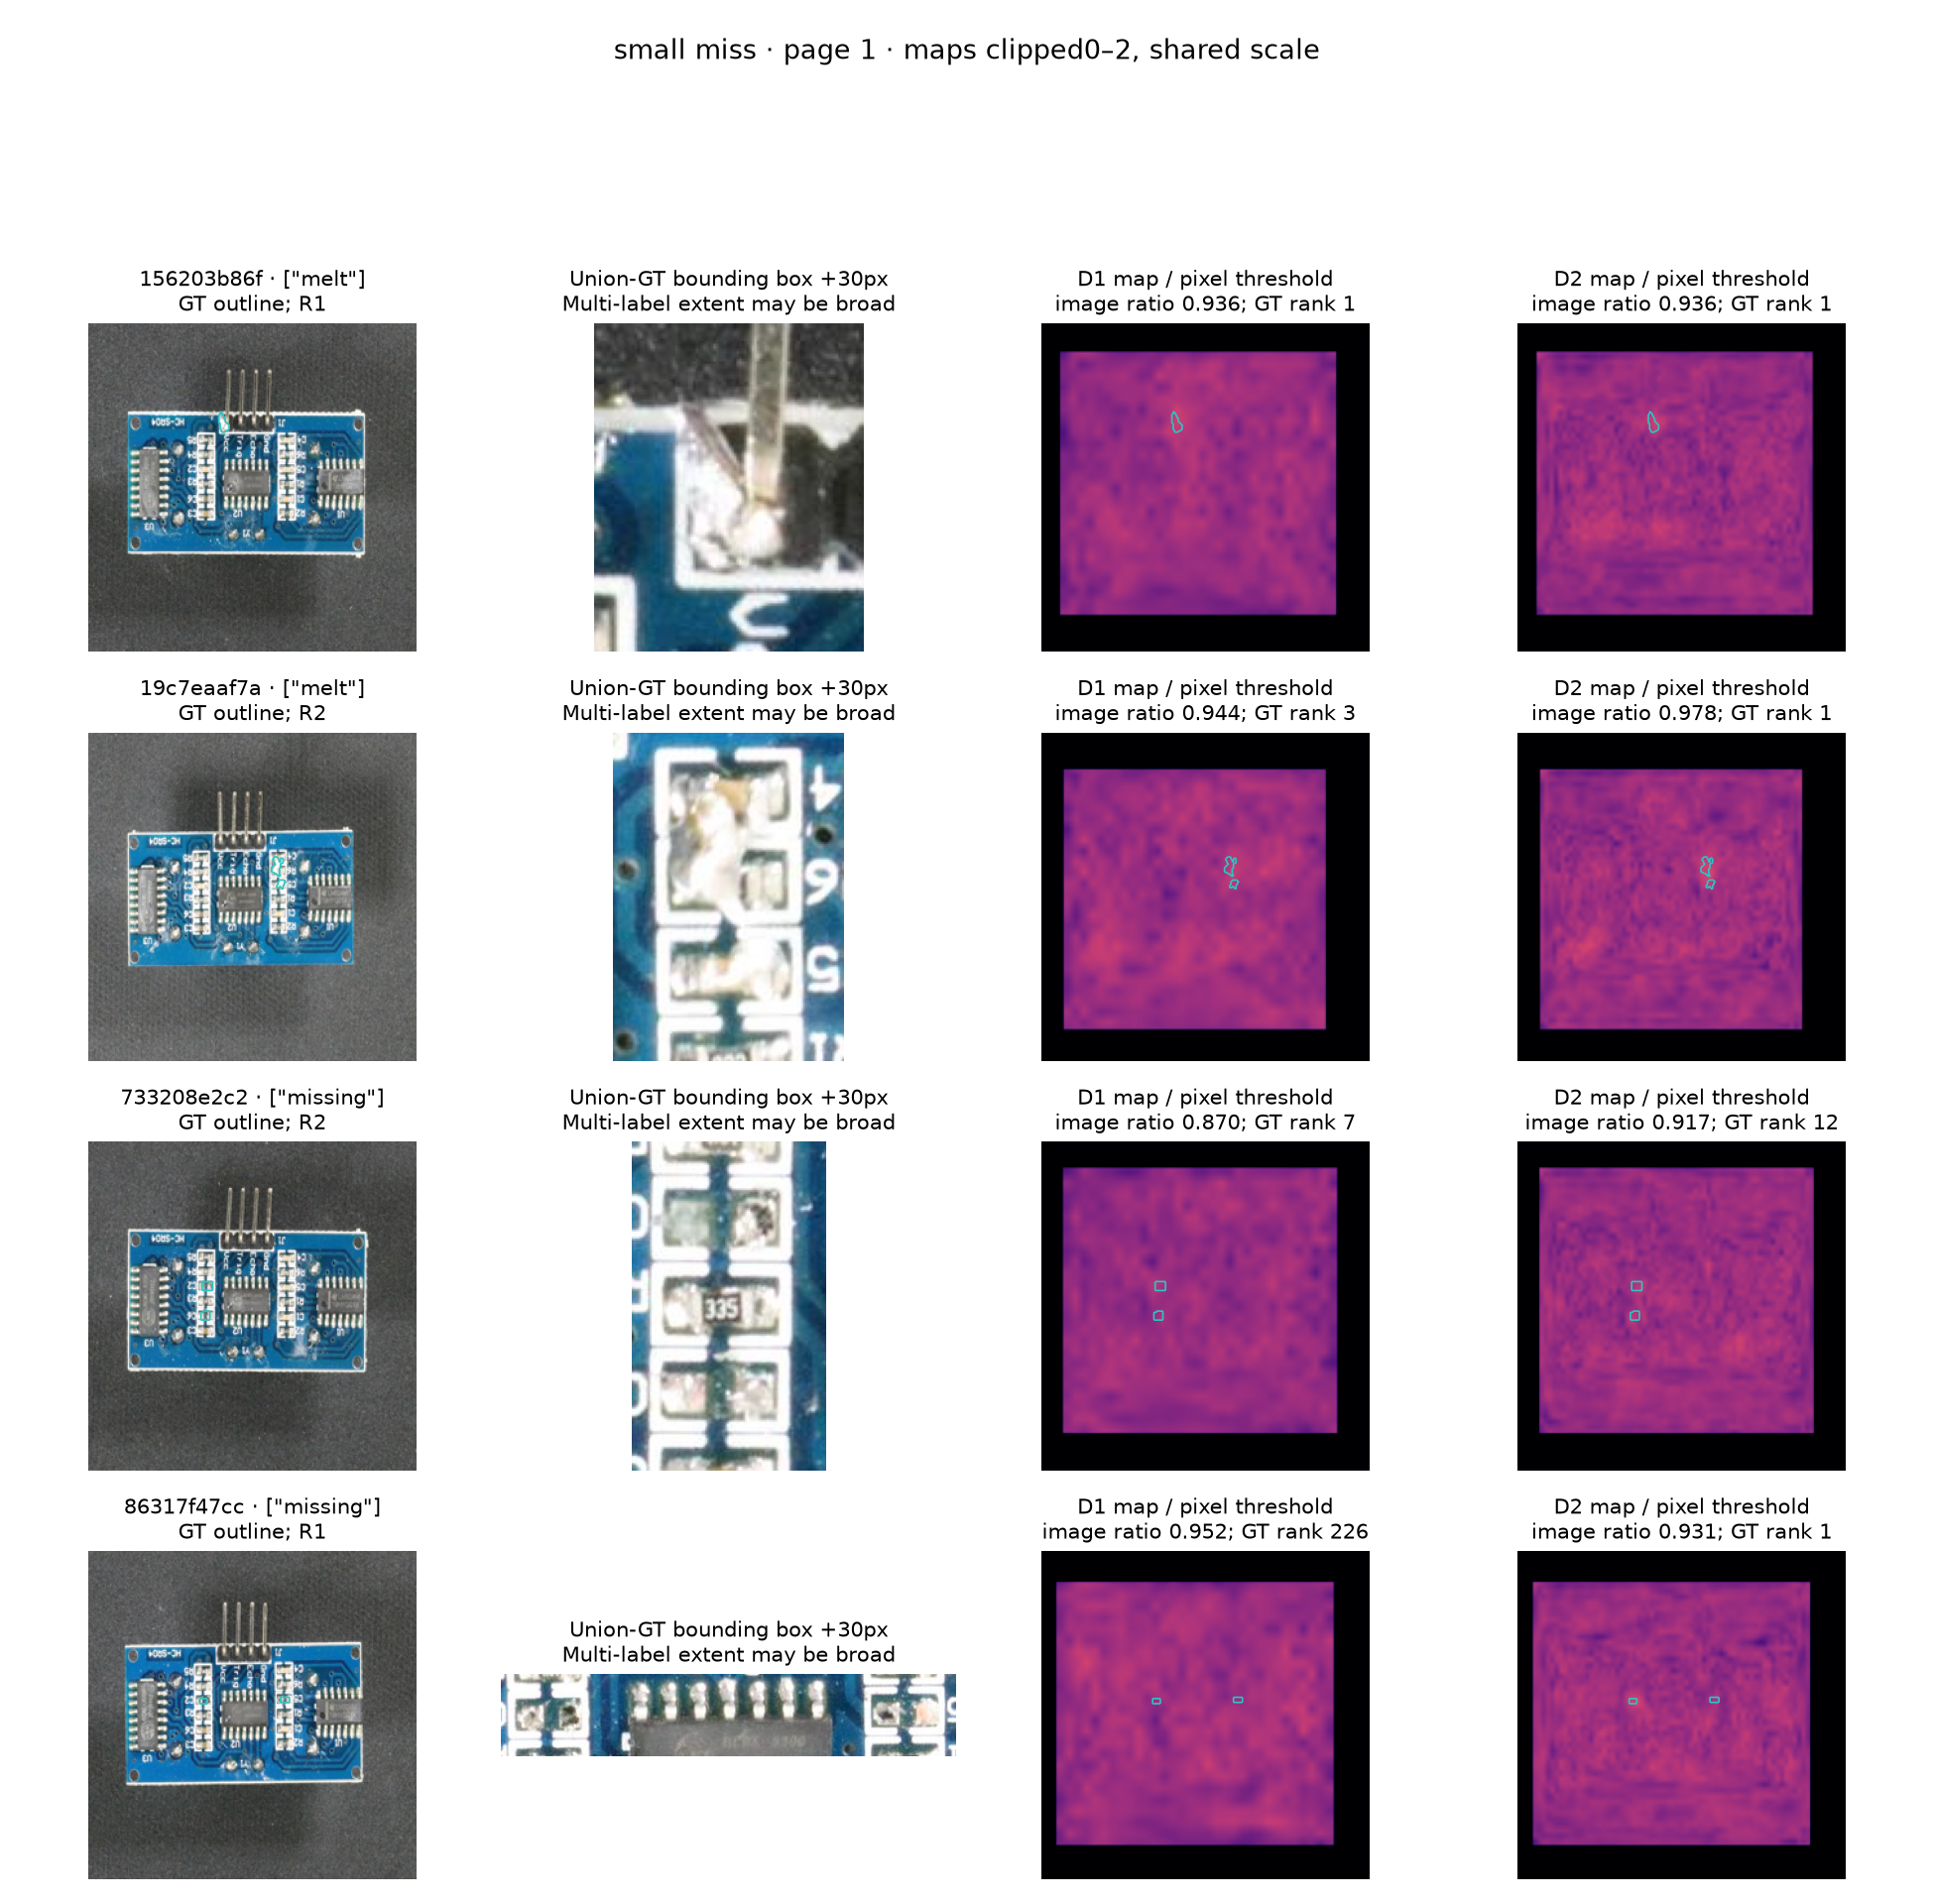

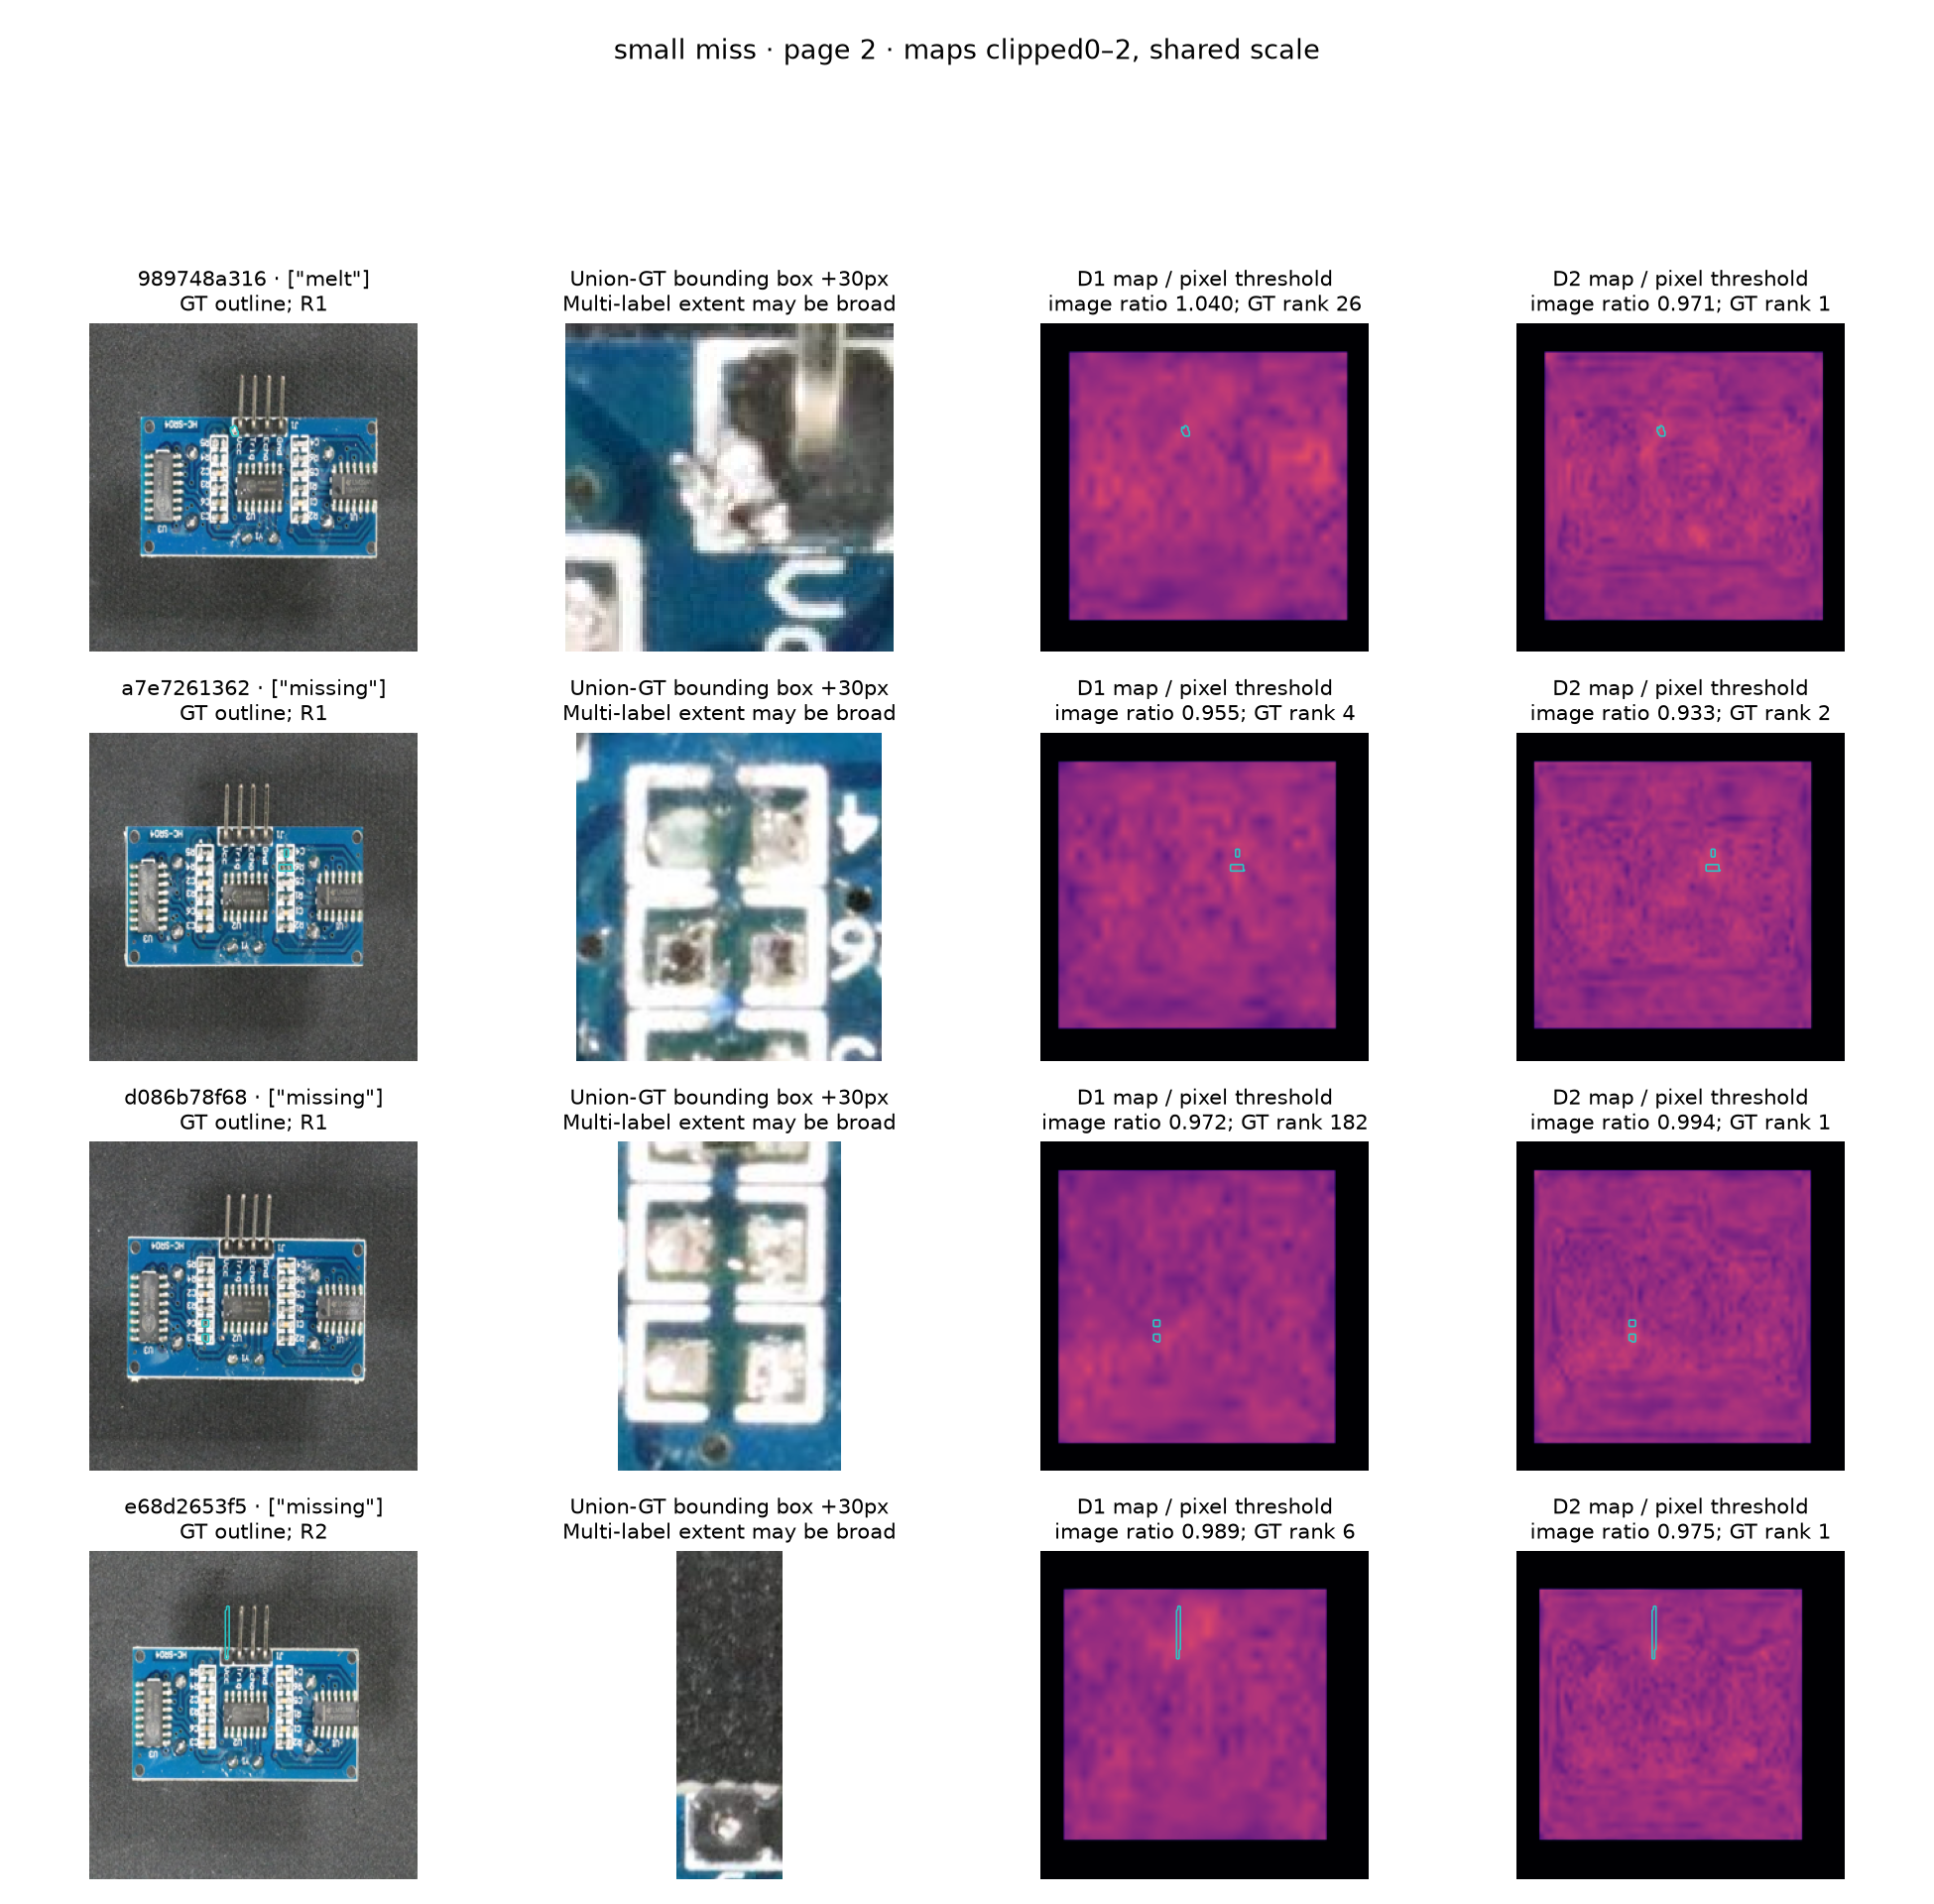

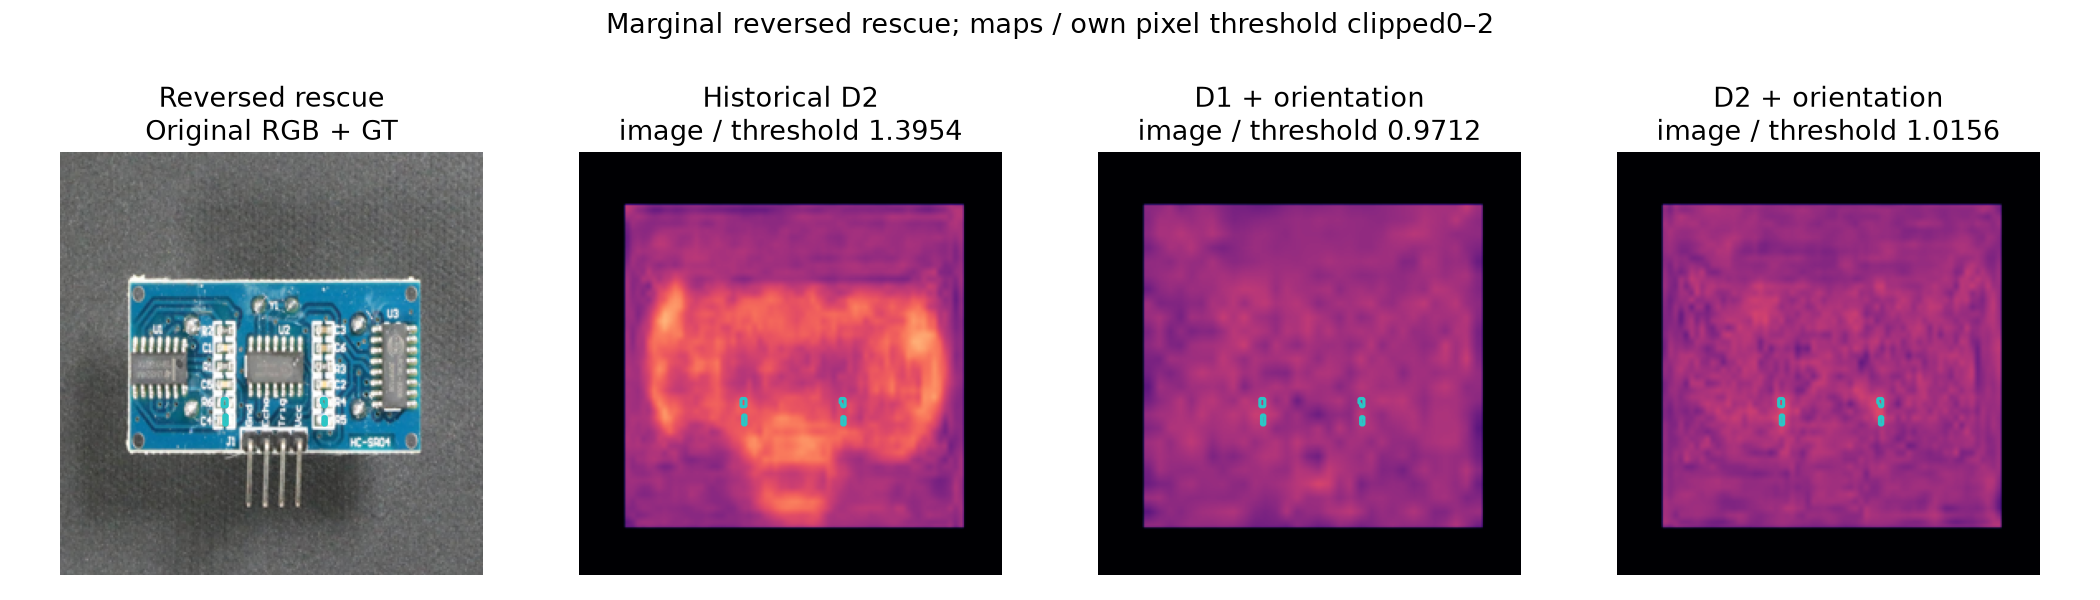

{'created_at_utc': '2026-10-06T03:31:14.394236+00:00',
 'decision': 'Branch D: recommend freeze current D2+orientation candidate; do not force Stage6B',
 'scope': 'Stage6A recommendation only; formal v1 receipt and final freeze not executed',
 'selected_stage6b_intervention': None,
 'distinct_target_misses': 9,
 'gt_peak_rank1_misses': 7,
 'first_gt_ranks': [1, 1, 1, 1, 1, 1, 1, 2, 12],
 'miss_image_ratio_range': [0.9174339403938256, 0.9937052307931596],
 'F1_distinct_misses': 0,
 'F4_distinct_misses': 5,
 'F2_distinct_misses': 1,
 'rationale': 'GT ranks usually strong; GT evidence close to image operating threshold. Distances are lower on misses; canonical missing-hit controls overlap, while per-image small-case nearest medians separate in this fixed cohort. No pervasive low-GT/poor-rank representation failure, no proof of pure resolution causality, and outside responses cannot cause max-score false negatives. Margin/limited separation is evident but no single allowed intervention has

In [3]:
metadata=json.loads((out/'figure_metadata.json').read_text())
for figure in metadata['figures']:
    display(Image(filename=str(root/figure['path'])))
display(json.loads((out/'decision_gate.json').read_text()))